# Neutral Mutation Rates for Sites of Interest

## Introduction

In our V family DASM analysis, we discovered an intriguing pattern at specific sites located at the edges of CDRs (main sites: 38, 55, 40, 57, 66). These sites exhibit a paradoxical combination of properties:

1. **Wide germline heterogeneity** - Multiple different amino acids are present across V gene families at these positions
2. **Entrenchment** - Despite this heterogeneity, there is a strong preference not to mutate between the different germline amino acids


We load entrenchment results from DASM analysis from _output/entrenchment_analysis (see vj_families_dasm for creation).

We separate sites into two types of evolutionarily constrained sites:
- **Within v family entrenched sites**
- **Between v-family entrenched sites**

Sites can get an entrenchment signal in both, and then it is unclear if the sites became entrenched at the evolutionary level while separating into v families or v genes.
For simplicity, we create a simple separation into sites that are entrenched within v families, and sites that are entrenched between v families and not within v families.
The "within v family" tend to cluster in and close to the CDRs, and the "between v families" can be seen in other places as well (cell 5). We can hypothesize that between v family sites are likely very constrained in the antibody, with other structural features in the antibody preventing a mutation to the previous state, and that the within v family sites are more related to binding and the antigen, as they are close/in CDR areas and also at sites that have high germline diversity.

## Get neutral mutation rates from thrifty
We examine the **neutral mutation rates** at these sites using the Thrifty model. Our hypothesis is that entrenchment might correlate with intrinsic mutational properties of these positions.

We calculate neutral mutation probabilities (cell 2) using:
- The Thrifty neutral mutation model to predict position-specific rates
- A standardized branch length of 0.1 to ensure comparable rates across sites and amino acids
- Calculate specific substitution probabilities: substitution_probability = probability * csp
- We calculate neutral probabilties per nucleotide>nucleotide, translate that to amino acid changes, and then aggregate to create two dataframes:
   - aa_neutral_df - neutral probabilitiy of specific amino acid to specific amino acid
   - aa_to_any_neutral_df - neutral probability of specific amino acid to any

## We find high neutral mutation rate for these sites

**Surprising Result**: Thrifty reveals that these entrenchment sites actually have **high neutral mutation rates** (cell 8). This is more true for the "within v family entrenched sites" and not so much for the "bewteen v family entrenched sites". For all of these analyses we focus on mutations away from the germline only. 

## Neutral rate and germline diversity
Hypothesis: looking at the v genes, some sites are more heterogenous then others. Perhaps site-level heterogeneity in V genes might be driven by underlying neutral mutation rates rather than selection, because the gene duplication events that create the germline diversity happen at the DNA level before any functional protein exists (can AID occur at the gamete level?). We can test this by comparing neutral mutation patterns (thrifty) to germline diversity (both the level of diversity per site and also specific mutations that occur).

We find that there is a correlation between shannon diversity at a site and neutral mutation rate (cell 16):
- There is a correlation of r^2=0.136 for mean median substitution probability per site vs shannon diversity per site on all data for V1, V3, V4. When we remove sites with diversity < 0.2, we get a higher correlation of r^2=0.195, unlike the correlation with selection factors which disappears after this filtration.
- Follow up - is the mutation pattern also correlated? We can check if the tree of the germline v genes is better explained by a model of the trhufty neutral rates site, compared to a uniform model.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from scipy.stats import pearsonr, spearmanr


from netam.models import DEFAULT_NEUTRAL_MODEL
from dnsmex.local import localify
from dnsmex.neutral_mutability import CachedMutabilityContainer
from dnsmex.dasm_oe import write_sites_oe
from utils import add_germline_information

figures_dir = localify("FIGURES_DIR")

In [2]:
MutabilityContainer = CachedMutabilityContainer(dataset="v1rodriguez", neutral_model_name=DEFAULT_NEUTRAL_MODEL)



Creating new MutabilityContainer data...
Loading /home/nharel/data/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI_noN_no-naive.csv.gz
Filtering out problematic pairs of sample_id and clonal families [('sample-igg-SC-18', '440')]
Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip


/home/nharel/re/dnsm-experiments-1/dnsmex/dxsm_data.py:474: UserWarning: Using ThriftyHumV0.2-59. Make sure this is an appropriate choice for your model, or use `netam.framework.add_shm_model_outputs_to_pcp_df` directly to provide the correct neutral model.
  warn(
Evaluating model: 100%|██████████| 2176/2176 [00:05<00:00, 400.72it/s]


Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip


Evaluating model: 100%|██████████| 21752/21752 [00:32<00:00, 675.14it/s]


Using ANARCI path: {'heavy': '/home/nharel/data/v3/anarci/rodriguez-airr-seq-race-prod-NoWinCheck_igh_imgt.csv'}
ANARCI seq length mismatch! sample-igg-SC-13 2013
ANARCI seq length mismatch! sample-igg-SC-15 925
Invalid IMGT insertion: 68.1 sample-igg-SC-18 440
ANARCI seq length mismatch! sample-igg-SC-19 1803
IMGT mismatch with CDR annotation! sample-igg-W-25 4
IMGT mismatch with CDR annotation! sample-igg-W-19 41
Invalid IMGT insertion: 119.1 sample-igg-W-37 140
IMGT mismatch with CDR annotation! sample-igg-W-37 1
Invalid IMGT insertion: 119.1 sample-igg-W-3 17
Invalid IMGT insertion: 119.1 sample-igg-W-34 200


Processing sequences to nucleotide-level rates: 100%|██████████| 21752/21752 [03:26<00:00, 105.51it/s]


Saving data to cache...
✓ Saved to cache:
  - /home/nharel/re/dnsm-experiments-1/_cache//mutability_ThriftyHumV0.2-59_v1rodriguez_nucleotide.csv
  - /home/nharel/re/dnsm-experiments-1/_cache//mutability_ThriftyHumV0.2-59_v1rodriguez_amino_acid.csv
  - /home/nharel/re/dnsm-experiments-1/_cache//mutability_ThriftyHumV0.2-59_v1rodriguez_amino_acid_to_any.csv
  - /home/nharel/re/dnsm-experiments-1/_cache//mutability_ThriftyHumV0.2-59_v1rodriguez_codon.csv
  - /home/nharel/re/dnsm-experiments-1/_cache//mutability_ThriftyHumV0.2-59_v1rodriguez_codon_to_any.csv
  - /home/nharel/re/dnsm-experiments-1/_cache//mutability_ThriftyHumV0.2-59_v1rodriguez_pcp_df.csv


In [3]:
# add germline information to all dataframes
MutabilityContainer.aa_neutral_df = add_germline_information(MutabilityContainer.pcp_df, MutabilityContainer.aa_neutral_df)
MutabilityContainer.aa_to_any_neutral_df = add_germline_information(MutabilityContainer.pcp_df, MutabilityContainer.aa_to_any_neutral_df)
MutabilityContainer.codon_neutral_df = add_germline_information(MutabilityContainer.pcp_df, MutabilityContainer.codon_neutral_df)
MutabilityContainer.codon_to_any_neutral_df = add_germline_information(MutabilityContainer.pcp_df, MutabilityContainer.codon_to_any_neutral_df)




Text(0.5, 1.0, 'Thrifty Substitution Probability (specific amino acid to any)')

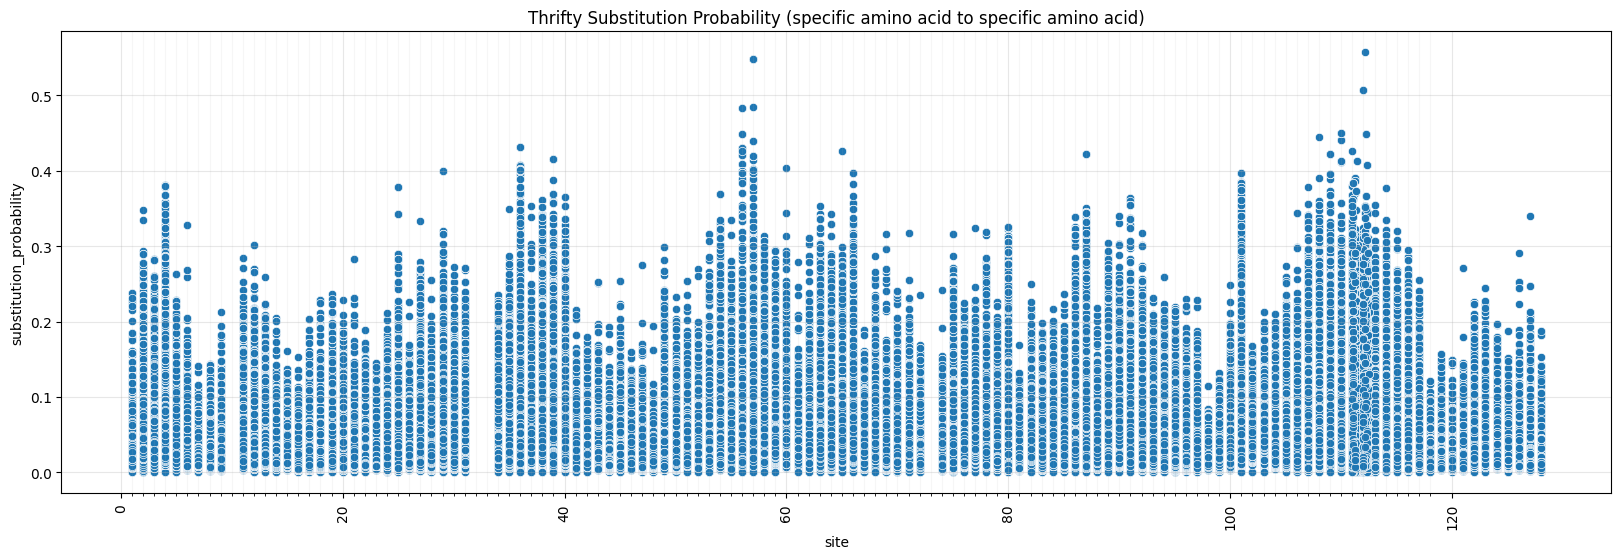

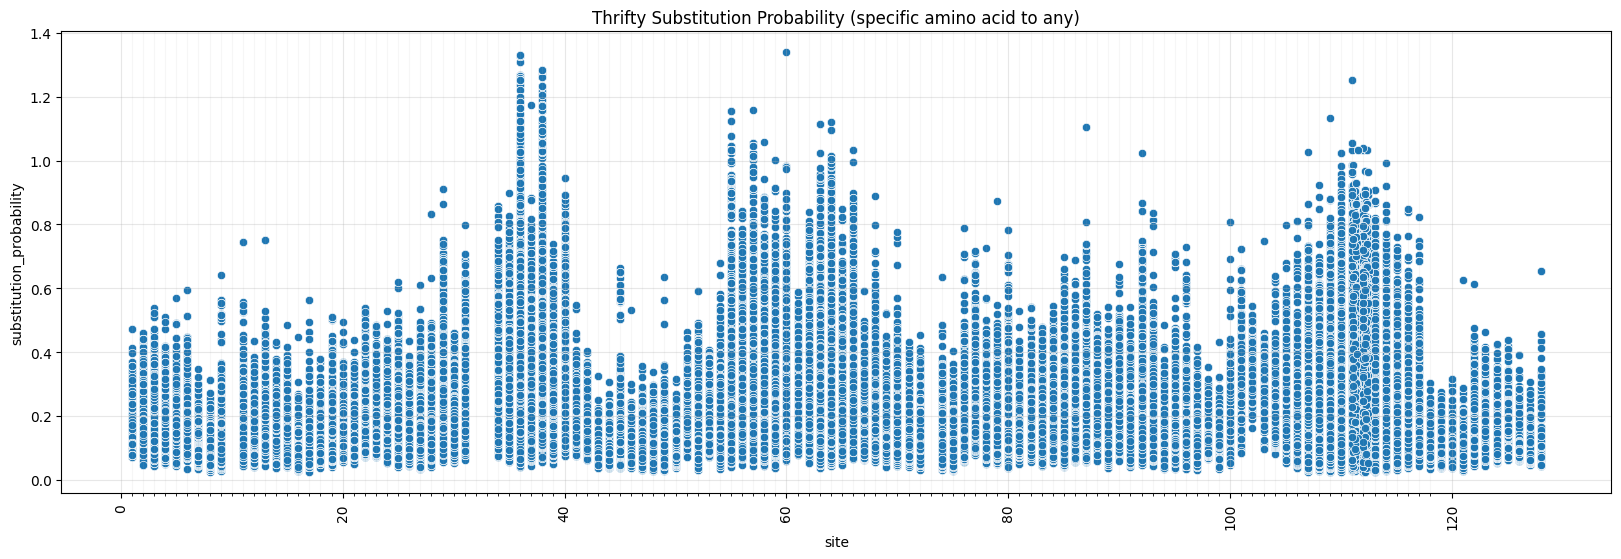

In [4]:
## View subsitution probabilites for specific amino acid to specific amino acid and from specific amino acid to any

fig, ax = plt.subplots(figsize=(20, 6))
sns.scatterplot(MutabilityContainer.aa_neutral_df, x='site', y='substitution_probability', ax=ax)

# Rotate labels
ax.tick_params(axis='x', rotation=90)
ax.grid(True, alpha=0.3)

# Add minor grid lines for every site
ax.set_xticks(range(0, 119), minor=True)
ax.grid(True, which='minor', alpha=0.1)
ax.set_title('Thrifty Substitution Probability (specific amino acid to specific amino acid)')




fig, ax = plt.subplots(figsize=(20, 6))
sns.scatterplot(MutabilityContainer.aa_to_any_neutral_df, x='site', y='substitution_probability', ax=ax)

# Rotate labels
ax.tick_params(axis='x', rotation=90)
ax.grid(True, alpha=0.3)

# Add minor grid lines for every site
ax.set_xticks(range(0, 119), minor=True)
ax.grid(True, which='minor', alpha=0.1)
ax.set_title('Thrifty Substitution Probability (specific amino acid to any)')


/tmp/ipykernel_971196/2012362620.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['site'] = plot_data['site'].astype(float)


/tmp/ipykernel_971196/2012362620.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['site'] = plot_data['site'].astype(float)
/tmp/ipykernel_971196/2012362620.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['site'] = plot_data['site'].astype(float)


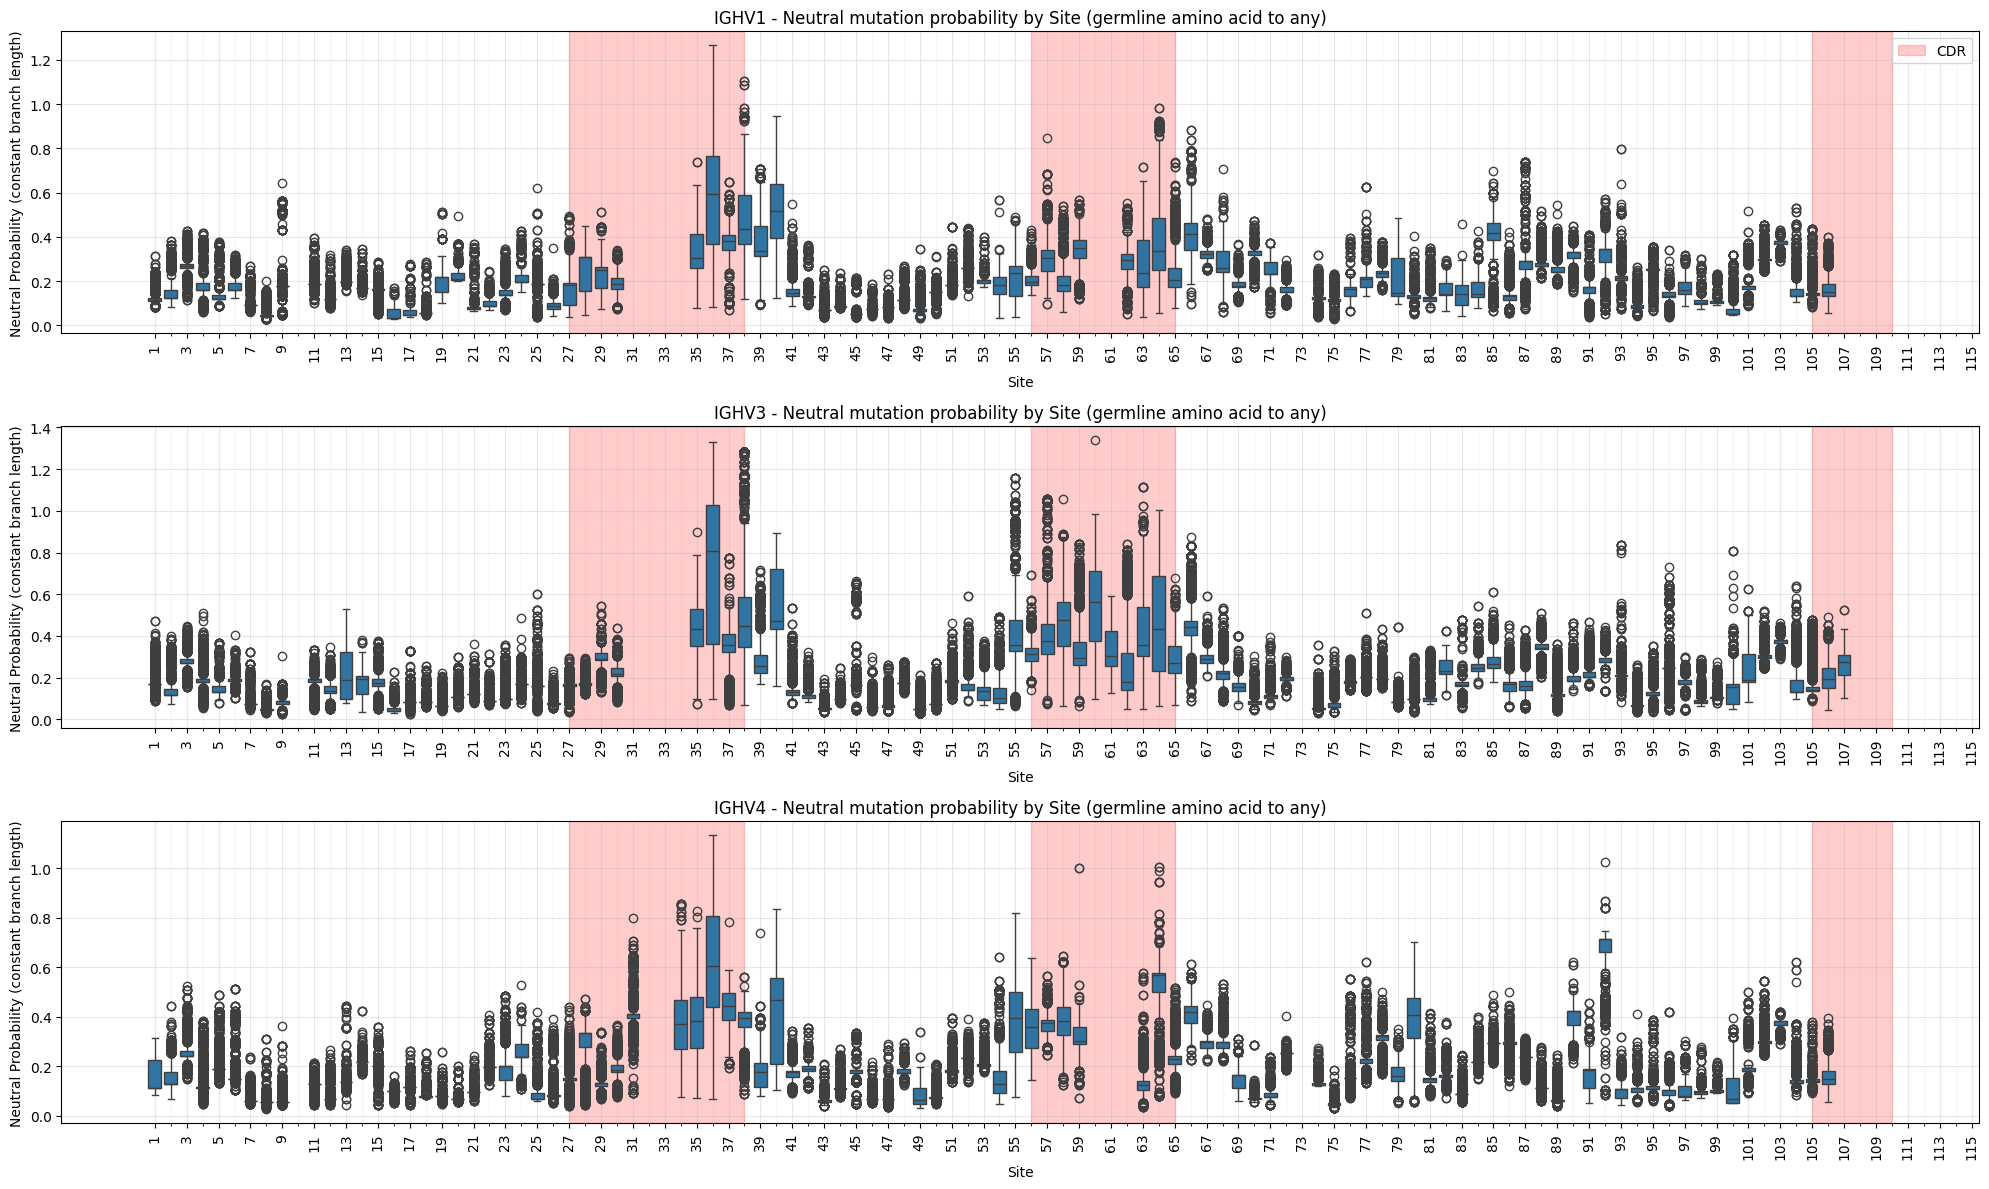

In [5]:
# View distributions of subsitution probabilites for specific amino acid to any amino acid by site, per V family



fig, axes = plt.subplots(3, 1, figsize=(20, 12))

v_families = ['IGHV1', 'IGHV3', 'IGHV4']

# Define CDR regions
cdr_regions = [
    (27, 38),   # CDR1
    (56, 65),   # CDR2
    (105, 110)  # CDR3 (shortened for V genes only)
]

for i, v_family in enumerate(v_families):
    # Filter data for current V family
    plot_data = MutabilityContainer.aa_to_any_neutral_df[
        (MutabilityContainer.aa_to_any_neutral_df.v_family == v_family) & 
        (MutabilityContainer.aa_to_any_neutral_df.is_germline_aa == True)
    ]
    plot_data['site'] = plot_data['site'].astype(float)
    
    # Get all unique pcp_index values to create dummy rows for missing sites
    unique_pcps = plot_data['pcp_index'].unique()
    
    # Create a complete grid of all pcp_index x site combinations
    complete_grid = []
    for pcp in unique_pcps:
        for site in range(1, 120):
            complete_grid.append({'pcp_index': pcp, 'site': site})
    
    complete_df = pd.DataFrame(complete_grid)
    
    # Merge with actual data, filling missing values with NaN
    plot_data_complete = pd.merge(complete_df, plot_data, on=['pcp_index', 'site'], how='left')
    
    # Create the boxplot with complete data (NaN values will be ignored automatically)
    sns.boxplot(data=plot_data_complete, x='site', y='substitution_probability', ax=axes[i])
    
    # Set x-axis ticks to show every 2nd site
    axes[i].set_xticks(range(0, 119, 2))
    axes[i].set_xticklabels(range(1, 120, 2))
    
    # Rotate labels
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].grid(True, alpha=0.3)
    
    # Add minor grid lines for every site
    axes[i].set_xticks(range(0, 119), minor=True)
    axes[i].grid(True, which='minor', alpha=0.1)
    
    # Add labels
    axes[i].set_xlabel('Site')
    axes[i].set_ylabel('Neutral Probability (constant branch length)')
    axes[i].set_title(f'{v_family} - Neutral mutation probability by Site (germline amino acid to any)')
    
    # Add CDR background regions - now the indexing matches site numbers directly
    for cdr_start, cdr_end in cdr_regions:
        # Convert from 1-based site numbering to 0-based boxplot indexing
        start_idx = cdr_start - 1
        end_idx = cdr_end - 1 
        axes[i].axvspan(start_idx, end_idx, alpha=0.2, color='red', 
                       label='CDR' if cdr_start == cdr_regions[0][0] else "")
    
    # Add legend only to the first plot to avoid repetition
    if i == 0:
        axes[i].legend()

plt.tight_layout()
plt.show()

### Entrenchment Site Classification - within v family and between



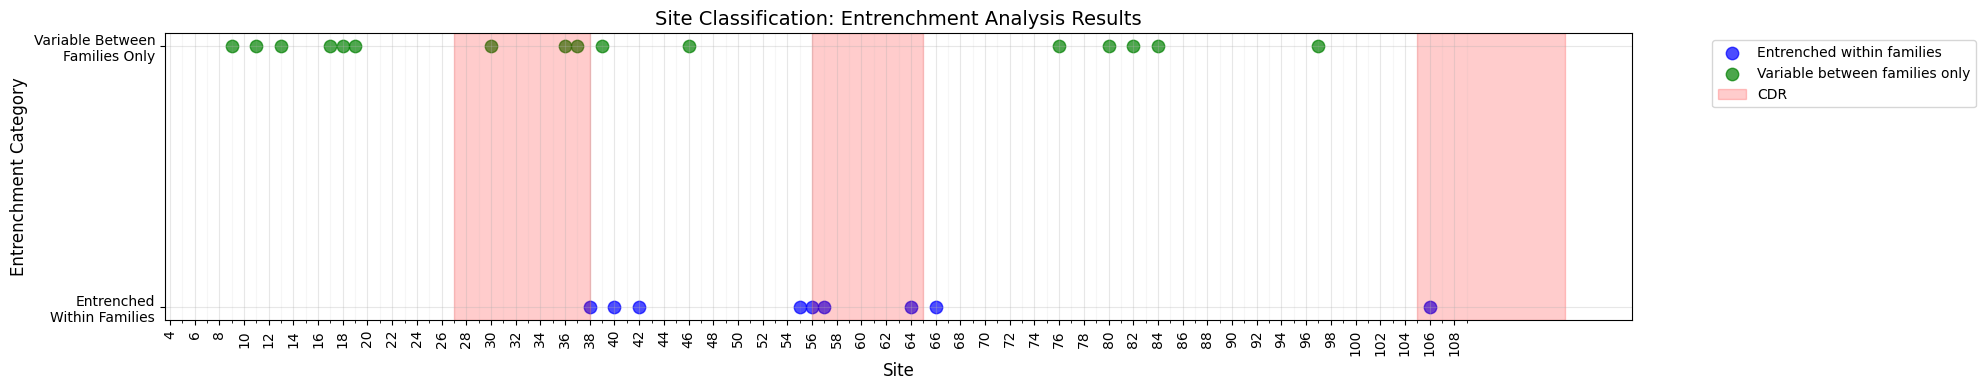

Entrenched within families: 9 sites
Entrenched between families only: 16 sites


In [6]:


# Define highlight sites and their colors
highlight_sites = {38: 'red', 55: 'orange', 40: 'green', 42: 'purple', 57: 'blue', 64: 'cyan', 66: 'magenta', 56:'brown', 106:'pink'}

# Load entrenchment data
entrenchment_directory = '_output/entrenchment_analysis/'

# Load "within" files and "vs" files separately
within_dfs = []
vs_dfs = []

for f in os.listdir(entrenchment_directory):
    file_path = os.path.join(entrenchment_directory, f)
    
    if 'within' in f:
        df = pd.read_csv(file_path)
        within_dfs.append(df)
    elif 'vs' in f:
        df = pd.read_csv(file_path)
        vs_dfs.append(df)

# Combine dataframes
within_combined = pd.concat(within_dfs, axis=0) if within_dfs else pd.DataFrame()
vs_combined = pd.concat(vs_dfs, axis=0) if vs_dfs else pd.DataFrame()

# Get unique sites from each analysis type
if not within_combined.empty:
    entrenched_within_sites = sorted(within_combined['site'].unique()) if 'site' in within_combined.columns else []
else:
    entrenched_within_sites = []

if not vs_combined.empty:
    vs_sites = set(vs_combined['site'].unique()) if 'site' in vs_combined.columns else set()
else:
    vs_sites = set()

# Sites that are in "vs" but not in "within" 
vs_only_sites = sorted(vs_sites - set(entrenched_within_sites))

# Create the filtered datasets
if not within_combined.empty:
    entrenched_within_df = within_combined.copy()
else:
    entrenched_within_df = pd.DataFrame()

if not vs_combined.empty:
    vs_only_df = vs_combined[vs_combined['site'].isin(vs_only_sites)].copy()
else:
    vs_only_df = pd.DataFrame()

# Update highlight sites for each category
entrenched_highlight_sites = {site: color for site, color in highlight_sites.items() 
                             if site in entrenched_within_sites}
vs_only_highlight_sites = {site: color for site, color in highlight_sites.items() 
                          if site in vs_only_sites}




fig, ax = plt.subplots(figsize=(20, 4))

# Define CDR regions (1-based site numbering)
cdr_regions = [(27, 38), (56, 65), (105, 117)]  # Example CDR1, CDR2, CDR3 regions

# Plot entrenched within sites
if entrenched_within_sites:
    ax.scatter(entrenched_within_sites, [1]*len(entrenched_within_sites), 
               s=80, alpha=0.7, color='blue', label='Entrenched within families')

# Plot vs-only sites (variable between but not within families)
if vs_only_sites:
    ax.scatter(vs_only_sites, [2]*len(vs_only_sites), 
               s=80, alpha=0.7, color='green', label='Variable between families only')

# Customize the plot
ax.set_xlabel('Site', fontsize=12)
ax.set_ylabel('Entrenchment Category', fontsize=12)
ax.set_yticks([1, 2])
ax.set_yticklabels(['Entrenched\nWithin Families', 'Variable Between\nFamilies Only'])
ax.set_title('Site Classification: Entrenchment Analysis Results', fontsize=14)

# Set x-axis limits based on data
all_sites = entrenched_within_sites + vs_only_sites
if all_sites:

    
    # Set x-axis ticks to show every 2nd site
    tick_start = 0  # Start a bit before first site
    tick_end = 110  # End a bit after last site
    ax.set_xticks(range(tick_start, tick_end, 2))
    
    # Rotate labels
    ax.tick_params(axis='x', rotation=90)
    ax.grid(True, alpha=0.3)
    
    # Add minor grid lines for every site
    ax.set_xticks(range(tick_start, tick_end), minor=True)
    ax.grid(True, which='minor', alpha=0.1)

# Add CDR background regions
for cdr_start, cdr_end in cdr_regions:
    ax.axvspan(cdr_start, cdr_end, alpha=0.2, color='red', 
               label='CDR' if cdr_start == cdr_regions[0][0] else "")

# Add legend
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Entrenched within families: {len(entrenched_within_sites)} sites")
print(f"Entrenched between families only: {len(vs_only_sites)} sites")



## compare thrifty rates (from specific aa to any) to DNSM

In [7]:
dataset_name = "v1rodriguez"
model_name = "dnsm_1m-v1jaffe+v1tang-joint"

crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try:
    site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")


except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        replace_title=True,
    )
    complete_plotter = complete_plotter["heavy"]


    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    for column_name in ['selection_factor', 'neutral_prob', 'prob']:
        site_sub_probs_df[column_name] = site_sub_probs_df[column_name].apply(lambda x: x.item() if hasattr(x, 'item') else x)


    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
    site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)


## add germline information
site_sub_probs_df = add_germline_information(pcp_df, site_sub_probs_df, germline_codons_path="germline/germline_codons.csv")


site_sub_probs_df['log_selection_factor'] = np.log(site_sub_probs_df['selection_factor'])


In [8]:
neutral_grouped_data = MutabilityContainer.aa_to_any_neutral_df[(MutabilityContainer.aa_to_any_neutral_df.is_germline_aa == True) & (MutabilityContainer.aa_to_any_neutral_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'current_aa', 'v_family', 'is_cdr'], sort=False).agg({'substitution_probability':'median'}).reset_index()
dnsm_grouped_data = site_sub_probs_df[(site_sub_probs_df.is_germline_aa == True) & (site_sub_probs_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'parent_aa', 'v_family'], sort=False).agg({'log_selection_factor':'median'}).reset_index()

compare_neutral_dnsm = pd.merge(neutral_grouped_data, dnsm_grouped_data.rename(columns={'parent_aa':'current_aa'}), on=['site', 'current_aa', 'v_family'], how='inner')
compare_neutral_dnsm['log_selection_factor'] = compare_neutral_dnsm['log_selection_factor'].clip(lower=-4)


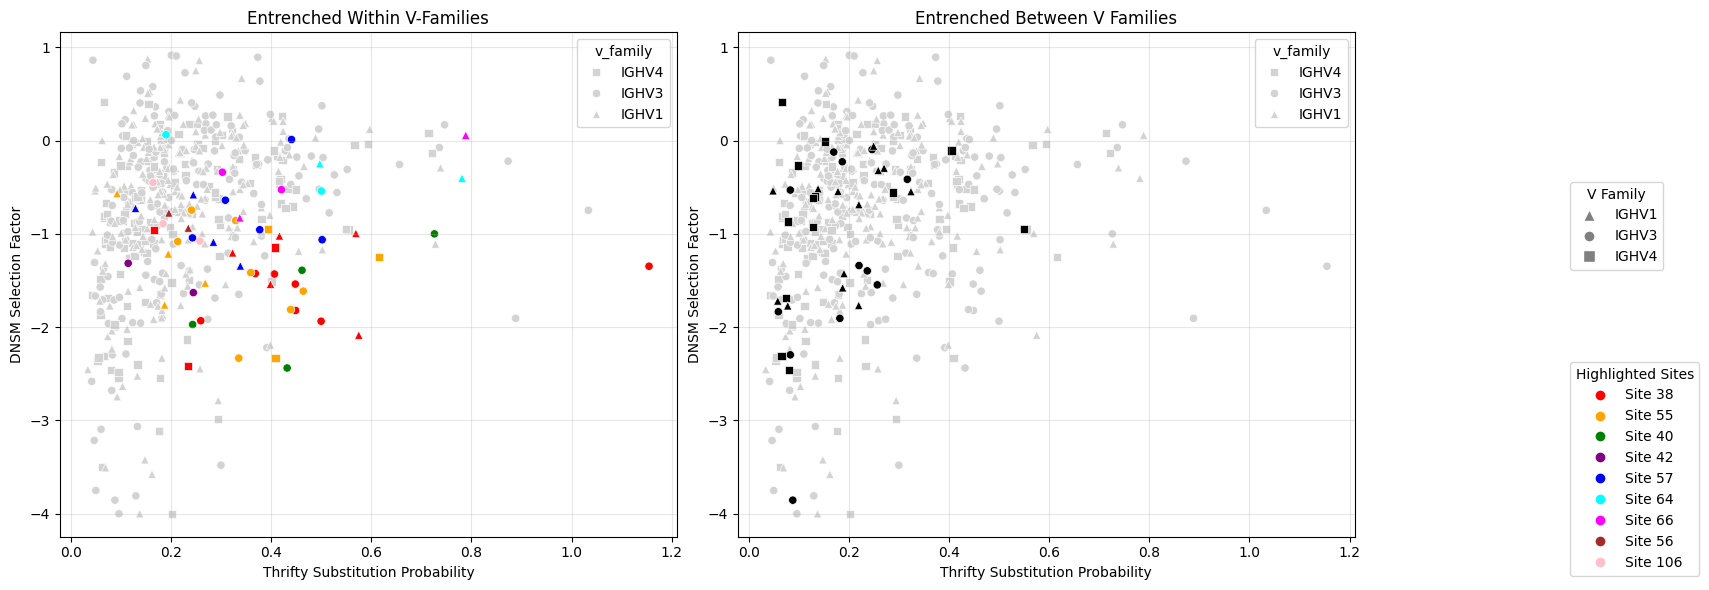

In [9]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Custom marker mapping
marker_map = {'IGHV1': '^', 'IGHV3': 'o', 'IGHV4': 's'}

def plot_entrenchment_category(ax, entrenchment_df, title, highlight_dict):
    # Base scatter plot
    sns.scatterplot(data=compare_neutral_dnsm, 
                    x='substitution_probability', 
                    y='log_selection_factor', 
                    style='v_family',
                    markers=marker_map,
                    color='lightgray',
                    ax=ax)
    
    # Overlay highlighted sites
    highlighted_data = pd.merge(compare_neutral_dnsm, 
                               entrenchment_df[['v_family', 'site', 'amino_acid']].drop_duplicates().rename(columns={'amino_acid':'current_aa'}), 
                               on=['v_family', 'site', 'current_aa'], 
                               how='inner')
    
    # Plot all sites in this entrenchment category
    for site in highlighted_data.site.drop_duplicates().tolist():
        color = highlight_dict.get(site, 'black')  # Use black if site not in highlight_dict
        site_data = highlighted_data[highlighted_data['site'] == site]
        if not site_data.empty:
            sns.scatterplot(data=site_data,
                           x='substitution_probability', 
                           y='log_selection_factor',
                           style='v_family',
                           markers=marker_map,
                           color=color,
                           ax=ax,
                           legend=False)
    
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel('Thrifty Substitution Probability')
    ax.set_ylabel('DNSM Selection Factor')

# Plot 1: Entrenched within families
plot_entrenchment_category(ax1, entrenched_within_df, 
                          'Entrenched Within V-Families', 
                          entrenched_highlight_sites)

# Plot 2: Variable between but not within families
plot_entrenchment_category(ax2, vs_only_df, 
                          'Entrenched Between V Families', 
                          vs_only_highlight_sites)

# Create legends
from matplotlib.lines import Line2D

# V-family legend (symbols)
v_family_elements = [Line2D([0], [0], marker=marker, color='w', markerfacecolor='gray', 
                           markersize=8, label=family, linestyle='None') 
                    for family, marker in marker_map.items()]

# Site color legend (only for sites that appear in plots)
all_highlighted_sites = {**entrenched_highlight_sites, **vs_only_highlight_sites}
site_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
                       markersize=8, label=f'Site {site}', linestyle='None') 
                for site, color in all_highlighted_sites.items()]

# Add legends to the right of the plots
fig.legend(handles=v_family_elements, title='V Family', 
          bbox_to_anchor=(0.98, 0.7), loc='upper left')
fig.legend(handles=site_elements, title='Highlighted Sites', 
          bbox_to_anchor=(0.98, 0.4), loc='upper left')

plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Make room for legends
plt.show()

## compare thrifty rates (from specific aa to specific aa) to DASM


In [10]:

dataset_name = "v1rodriguez"
model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"


crepe_prefix = localify(f"DASM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DASM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try: # load data if already computed
    
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")
    aa_site_subs_selection_df = pd.read_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv")

except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dasm_zoo.write_branch_lengths(localify(f"DASM_TRAINED_MODELS_DIR/{model_name}"), dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        #v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
        replace_title=True,
    )
    complete_plotter = complete_plotter["heavy"]

    pcp_df = complete_plotter.pcp_df.copy()
    aa_site_subs_selection_df = complete_plotter.aa_site_subs_selection_df.copy()

    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
    aa_site_subs_selection_df.to_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv", index=False)

## add germline information
aa_site_subs_selection_df_germline = add_germline_information(pcp_df, aa_site_subs_selection_df, germline_codons_path="germline/germline_codons.csv")


aa_site_subs_selection_df_germline['log_selection_factor'] = np.log(aa_site_subs_selection_df_germline['selection_factor'])


In [11]:
neutral_grouped_data = MutabilityContainer.aa_neutral_df[(MutabilityContainer.aa_neutral_df.is_germline_aa == True) & (MutabilityContainer.aa_neutral_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'current_aa', 'transition_aa', 'v_family', 'is_cdr'], sort=False).agg({'substitution_probability':'median'}).reset_index()
dasm_grouped_data = aa_site_subs_selection_df_germline[(aa_site_subs_selection_df_germline.is_germline_aa == True) & (aa_site_subs_selection_df_germline.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'parent_aa', 'selection_factor_target_aa', 'v_family'], sort=False).agg({'log_selection_factor':'median'}).reset_index()

compare_neutral_dasm = pd.merge(neutral_grouped_data, dasm_grouped_data.rename(columns={'parent_aa':'current_aa', 'selection_factor_target_aa':'transition_aa'}), on=['site', 'current_aa', 'transition_aa', 'v_family'], how='inner')
compare_neutral_dasm['log_selection_factor'] = compare_neutral_dasm['log_selection_factor'].clip(lower=-4)


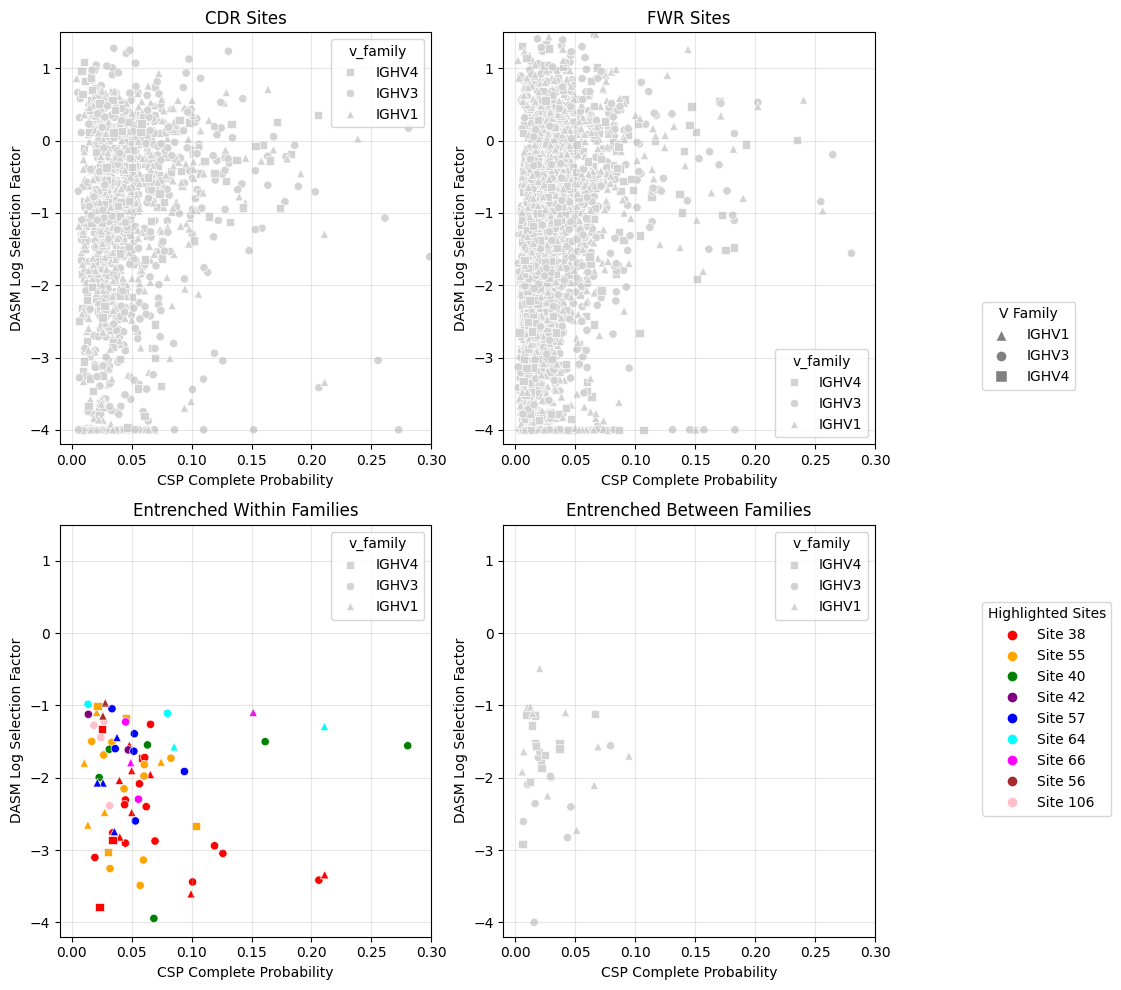

In [12]:
# Create four scatter plots
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

# Custom marker mapping
marker_map = {'IGHV1': '^', 'IGHV3': 'o', 'IGHV4': 's'}

def plot_category(ax, data, title, use_site_colors=False, highlight_dict=None):
    """Helper function to create consistent plots"""
    # Base scatter plot
    sns.scatterplot(data=data, 
                    x='substitution_probability', 
                    y='log_selection_factor', 
                    style='v_family',
                    markers=marker_map,
                    color='lightgray',
                    ax=ax)
    
    # Overlay site colors if specified
    if use_site_colors and highlight_dict:
        for site in data.site.drop_duplicates().tolist():
            color = highlight_dict.get(site, 'black')
            site_data = data[data['site'] == site]
            if not site_data.empty:
                sns.scatterplot(data=site_data,
                               x='substitution_probability', 
                               y='log_selection_factor',
                               style='v_family',
                               markers=marker_map,
                               color=color,
                               ax=ax,
                               legend=False)
    
    ax.set_title(title)
    ax.set_xlabel('CSP Complete Probability')
    ax.set_ylabel('DASM Log Selection Factor')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.01, 0.3)
    ax.set_ylim(-4.2, 1.5)

# Prepare datasets
cdr_data = compare_neutral_dasm[compare_neutral_dasm['is_cdr'] == True]
fwr_data = compare_neutral_dasm[compare_neutral_dasm['is_cdr'] == False]

highlight_data = pd.merge(compare_neutral_dasm, 
                         entrenched_within_df[['v_family', 'site', 'amino_acid', 'target_amino_acid']].drop_duplicates().rename(columns={'amino_acid':'current_aa', 'target_amino_acid':'transition_aa'}), 
                         on=['v_family', 'site', 'current_aa', 'transition_aa'], 
                         how='inner')

vs_only_plot_data = pd.merge(compare_neutral_dasm, 
                            vs_only_df[['v_family', 'site', 'amino_acid', 'target_amino_acid']].drop_duplicates().rename(columns={'amino_acid':'current_aa', 'target_amino_acid':'transition_aa'}), 
                            on=['v_family', 'site', 'current_aa', 'transition_aa'], 
                            how='inner')

# Create plots
plot_category(axes[0], cdr_data, 'CDR Sites')
plot_category(axes[1], fwr_data, 'FWR Sites')
plot_category(axes[2], highlight_data, 'Entrenched Within Families', 
              use_site_colors=True, highlight_dict=entrenched_highlight_sites)
plot_category(axes[3], vs_only_plot_data, 'Entrenched Between Families', 
              use_site_colors=True, highlight_dict=vs_only_highlight_sites)

# Create legends
from matplotlib.lines import Line2D

# V-family legend (symbols)
v_family_elements = [Line2D([0], [0], marker=marker, color='w', markerfacecolor='gray', 
                           markersize=8, label=family, linestyle='None') 
                    for family, marker in marker_map.items()]

# Site color legend (only for sites that appear in highlighted plots)
all_highlighted_sites = {**entrenched_highlight_sites, **vs_only_highlight_sites}
site_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
                       markersize=8, label=f'Site {site}', linestyle='None') 
                for site, color in all_highlighted_sites.items()]

# Add legends to the right of the plots
if site_elements:  # Only add site legend if there are highlighted sites
    fig.legend(handles=v_family_elements, title='V Family', 
              bbox_to_anchor=(0.98, 0.7), loc='upper left')
    fig.legend(handles=site_elements, title='Highlighted Sites', 
              bbox_to_anchor=(0.98, 0.4), loc='upper left')
else:
    fig.legend(handles=v_family_elements, title='V Family', 
              bbox_to_anchor=(0.98, 0.5), loc='center left')

plt.tight_layout()
plt.subplots_adjust(right=0.88)  # Make room for legends
plt.show()

## Neutral rates correlate with germline diversity?
Weak but significant correlation. Higher than selection factor correlation.

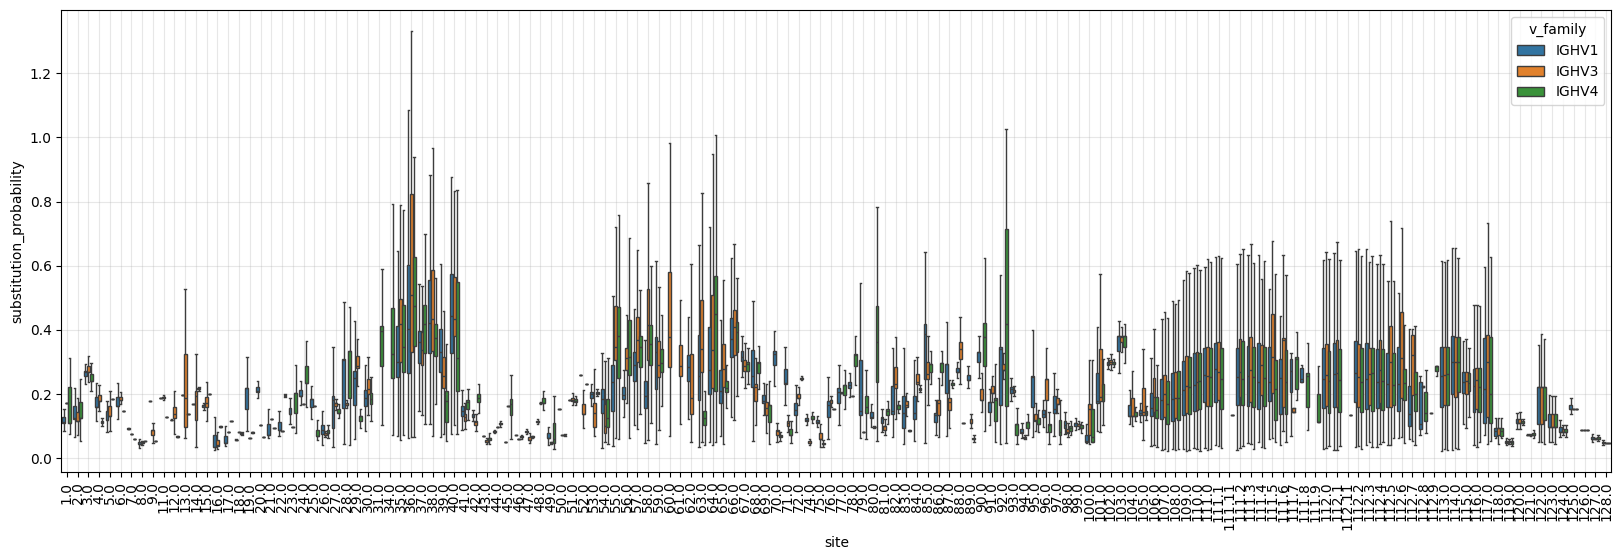

In [13]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.boxplot(MutabilityContainer.aa_to_any_neutral_df, x='site', y='substitution_probability', hue='v_family', hue_order=['IGHV1', 'IGHV3', 'IGHV4'], ax=ax, showfliers=False)
ax.tick_params(axis='x', rotation=90)
ax.grid(True, alpha=0.3)

In [14]:
germline_df = pd.read_csv('germline/germline_codons.csv')
germline_df = germline_df[germline_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4'])]

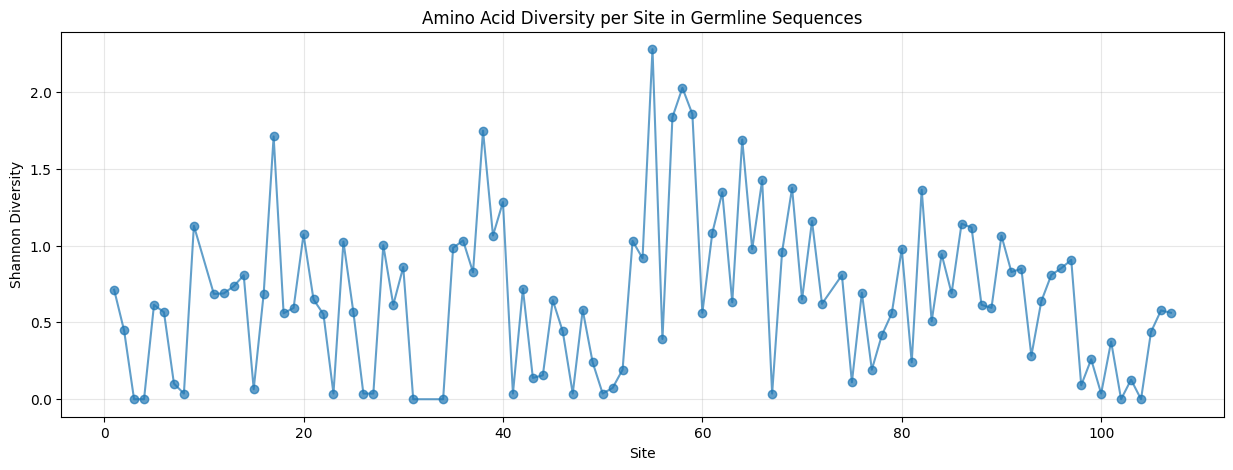

In [15]:
# calculate shannon diversity per site for V1, V3, V4 germline sequences toget


def shannon_diversity(series):
    """Calculate Shannon diversity index"""
    counts = series.value_counts()
    proportions = counts / counts.sum()
    return -np.sum(proportions * np.log(proportions))

# Calculate Shannon diversity per site
shannon_per_site = germline_df.groupby('site')['amino_acid'].apply(shannon_diversity).reset_index()
shannon_per_site.columns = ['site', 'shannon_diversity']

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(shannon_per_site['site'], shannon_per_site['shannon_diversity'], 'o-', alpha=0.7)
plt.xlabel('Site')
plt.ylabel('Shannon Diversity')
plt.title('Amino Acid Diversity per Site in Germline Sequences')
plt.grid(True, alpha=0.3)
plt.show()



IGHV1 - Sites with highest diversity:
    site  shannon_diversity  num_unique_aa
53    59           1.665216              7
54    62           1.611180              6
56    64           1.588536              6
51    57           1.412440              6
73    82           1.323495              5

IGHV3 - Sites with highest diversity:
     site  shannon_diversity  num_unique_aa
147    55           2.102364             10
130    38           1.886003              9
156    64           1.729499              8
151    59           1.712711              7
150    58           1.587512              8

IGHV4 - Sites with highest diversity:
     site  shannon_diversity  num_unique_aa
214    17           1.179404              4
250    55           1.052972              4
253    58           0.900256              3
233    38           0.831185              3
231    36           0.790987              3

Shannon diversity comparison across families (first 20 sites):
v_family     IGHV1     IGHV3     

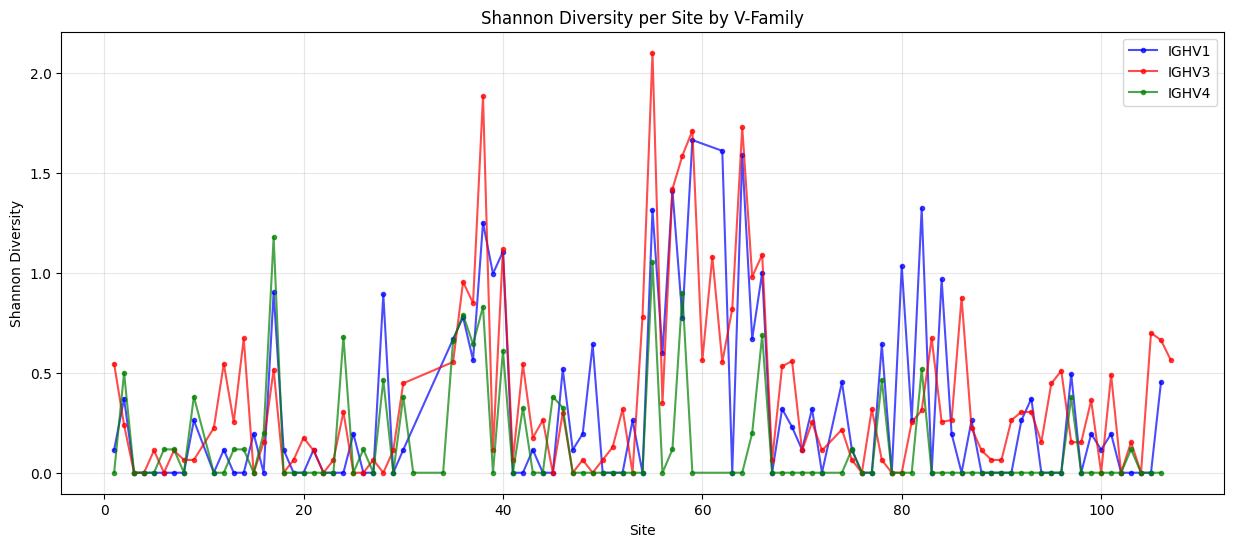

In [16]:
# calculate shannon diversity per site for each v famile V1, V3, V4 


# Calculate Shannon diversity per site within each v_family
diversity_by_family = germline_df.groupby(['v_family', 'site'])['amino_acid'].agg([
    ('num_unique_aa', 'nunique'),
    ('total_v_genes', 'count'),
    ('shannon_diversity', shannon_diversity)
]).reset_index()

# View results for each family
for family in ['IGHV1', 'IGHV3', 'IGHV4']:
    family_data = diversity_by_family[diversity_by_family['v_family'] == family]
    print(f"\n{family} - Sites with highest diversity:")
    print(family_data.nlargest(5, 'shannon_diversity')[['site', 'shannon_diversity', 'num_unique_aa']])

# Compare diversity across families for the same sites
pivot_diversity = diversity_by_family.pivot(index='site', columns='v_family', values='shannon_diversity').fillna(0)
print("\nShannon diversity comparison across families (first 20 sites):")
print(pivot_diversity.head(20))

# Calculate average diversity per family
avg_diversity = diversity_by_family.groupby('v_family')['shannon_diversity'].agg(['mean', 'std', 'count'])
print("\nAverage Shannon diversity per v_family:")
print(avg_diversity)

plt.figure(figsize=(15, 6))

for family, color in zip(['IGHV1', 'IGHV3', 'IGHV4'], ['blue', 'red', 'green']):
    family_data = diversity_by_family[diversity_by_family['v_family'] == family]
    plt.plot(family_data['site'], family_data['shannon_diversity'], 
             'o-', color=color, alpha=0.7, label=family, markersize=3)

plt.xlabel('Site')
plt.ylabel('Shannon Diversity')
plt.title('Shannon Diversity per Site by V-Family')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Correlations for All Data (Pooled across V-families):
Shannon Diversity vs Substitution Probability:
  r = 0.368, r² = 0.136, p = 0.000
Shannon Diversity vs Log Selection Factor:
  r = 0.396, r² = 0.157, p = 0.000
Shannon Diversity vs Selection Factor:
  r = 0.352, r² = 0.124, p = 0.000
Sample size: 103 sites


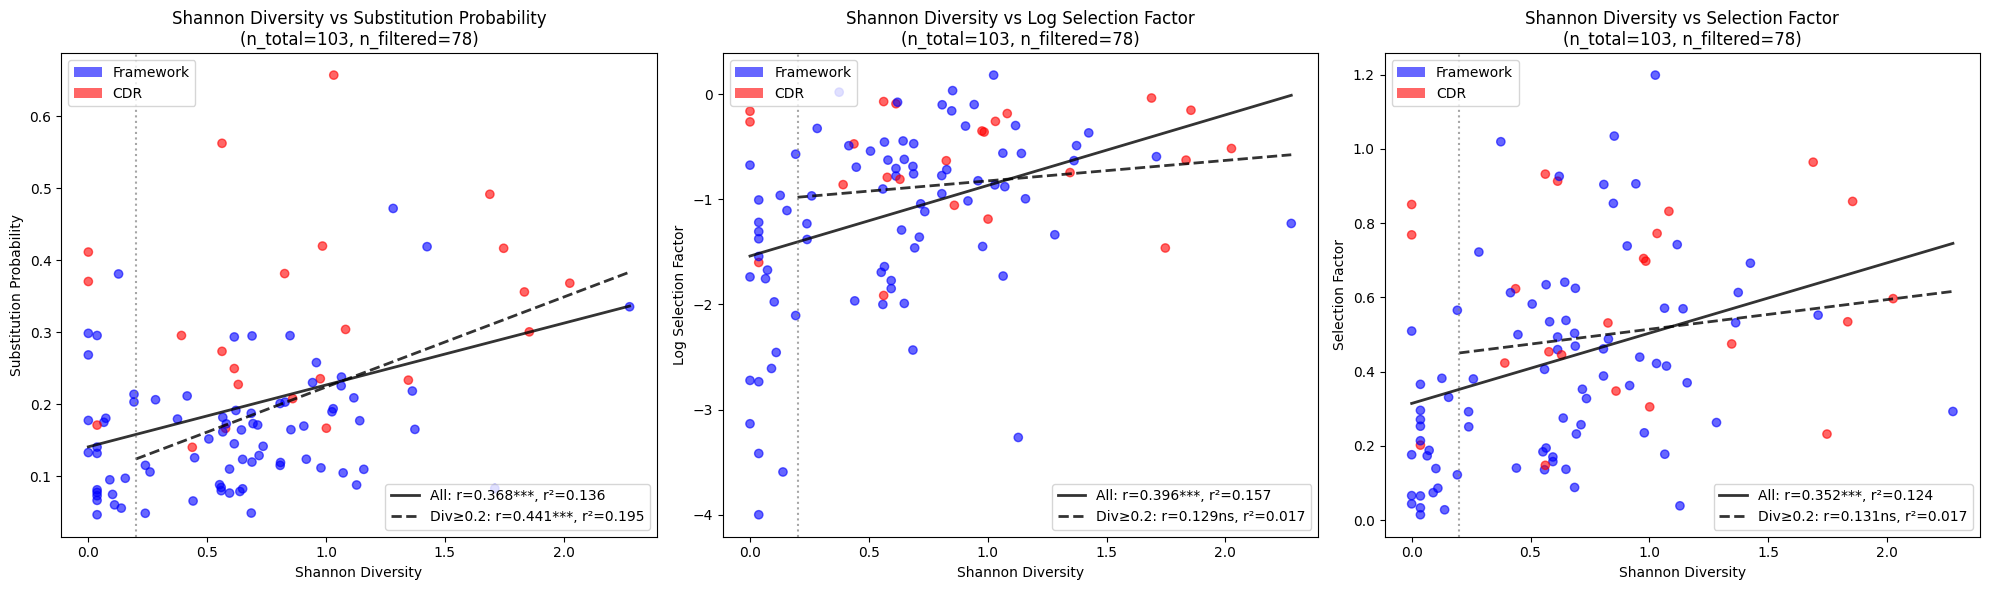

Solid line = regression using all data
Dashed line = regression using only diversity ≥ 0.2
Gray dotted line = diversity cutoff at 0.2
Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant


In [17]:
# compare neutral substitution probabilities and DNSM selection factors with shannon diversity, group per site (all v families together). Only use 
# amino acids at their germline state to calculate median substitution probabilities.

neutral_grouped_data = MutabilityContainer.aa_to_any_neutral_df[(MutabilityContainer.aa_to_any_neutral_df.is_germline_aa == True) & (MutabilityContainer.aa_to_any_neutral_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'is_cdr'], sort=False).agg({'substitution_probability':'median'}).reset_index()
dnsm_grouped_data = site_sub_probs_df[(site_sub_probs_df.is_germline_aa == True) & (site_sub_probs_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site',], sort=False).agg({'log_selection_factor':'median', 'selection_factor':'median'}).reset_index()

compare_neutral_dnsm3 = pd.merge(neutral_grouped_data, dnsm_grouped_data, on=['site', ], how='inner')
compare_neutral_dnsm3['log_selection_factor'] = compare_neutral_dnsm3['log_selection_factor'].clip(lower=-4)


# Calculate diversity across all families (pooled)
diversity_all_families = germline_df.groupby('site')['amino_acid'].apply(shannon_diversity).reset_index()
diversity_all_families.columns = ['site', 'shannon_diversity']

# Merge with your grouped data
merged_all_data = pd.merge(compare_neutral_dnsm3, diversity_all_families, on='site', how='inner')

# Add selection factor (non-log) if not already present
if 'selection_factor' not in merged_all_data.columns:
    merged_all_data['selection_factor'] = np.exp(merged_all_data['log_selection_factor'])

# Calculate correlations for all data pooled together
corr_subst_all, p_subst_all = pearsonr(merged_all_data['shannon_diversity'], 
                                      merged_all_data['substitution_probability'])
corr_log_sel_all, p_log_sel_all = pearsonr(merged_all_data['shannon_diversity'], 
                                          merged_all_data['log_selection_factor'])
corr_sel_all, p_sel_all = pearsonr(merged_all_data['shannon_diversity'], 
                                  merged_all_data['selection_factor'])

# Calculate r-squared
r2_subst_all = corr_subst_all ** 2
r2_log_sel_all = corr_log_sel_all ** 2
r2_sel_all = corr_sel_all ** 2

# Display results
print("Correlations for All Data (Pooled across V-families):")
print(f"Shannon Diversity vs Substitution Probability:")
print(f"  r = {corr_subst_all:.3f}, r² = {r2_subst_all:.3f}, p = {p_subst_all:.3f}")
print(f"Shannon Diversity vs Log Selection Factor:")
print(f"  r = {corr_log_sel_all:.3f}, r² = {r2_log_sel_all:.3f}, p = {p_log_sel_all:.3f}")
print(f"Shannon Diversity vs Selection Factor:")
print(f"  r = {corr_sel_all:.3f}, r² = {r2_sel_all:.3f}, p = {p_sel_all:.3f}")
print(f"Sample size: {len(merged_all_data)} sites")


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))  # Added third subplot

def get_significance_stars(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"

# Filter data for second regression (diversity >= 0.2)
filtered_data = merged_all_data[merged_all_data['shannon_diversity'] >= 0.2]

# Add selection factor if not already present
if 'selection_factor' not in merged_all_data.columns:
    merged_all_data['selection_factor'] = np.exp(merged_all_data['log_selection_factor'])
    filtered_data['selection_factor'] = np.exp(filtered_data['log_selection_factor'])

# Calculate correlations for both datasets
# All data
corr_subst_all, p_subst_all = pearsonr(merged_all_data['shannon_diversity'], 
                                      merged_all_data['substitution_probability'])
corr_log_sel_all, p_log_sel_all = pearsonr(merged_all_data['shannon_diversity'], 
                                          merged_all_data['log_selection_factor'])
corr_sel_all, p_sel_all = pearsonr(merged_all_data['shannon_diversity'], 
                                  merged_all_data['selection_factor'])

r2_subst_all = corr_subst_all ** 2
r2_log_sel_all = corr_log_sel_all ** 2
r2_sel_all = corr_sel_all ** 2

# Filtered data (diversity >= 0.2)
corr_subst_filt, p_subst_filt = pearsonr(filtered_data['shannon_diversity'], 
                                        filtered_data['substitution_probability'])
corr_log_sel_filt, p_log_sel_filt = pearsonr(filtered_data['shannon_diversity'], 
                                            filtered_data['log_selection_factor'])
corr_sel_filt, p_sel_filt = pearsonr(filtered_data['shannon_diversity'], 
                                    filtered_data['selection_factor'])

r2_subst_filt = corr_subst_filt ** 2
r2_log_sel_filt = corr_log_sel_filt ** 2
r2_sel_filt = corr_sel_filt ** 2

# Plot 1: Shannon vs Substitution Probability
ax1.scatter(merged_all_data['shannon_diversity'], 
           merged_all_data['substitution_probability'], 
           alpha=0.6, c=merged_all_data['is_cdr'].map({True: 'red', False: 'blue'}))

z1_all = np.polyfit(merged_all_data['shannon_diversity'], 
                   merged_all_data['substitution_probability'], 1)
p1_all = np.poly1d(z1_all)
x_range_all = np.linspace(merged_all_data['shannon_diversity'].min(), 
                         merged_all_data['shannon_diversity'].max(), 100)
ax1.plot(x_range_all, p1_all(x_range_all), "k-", alpha=0.8, linewidth=2, 
         label=f'All: r={corr_subst_all:.3f}{get_significance_stars(p_subst_all)}, r²={r2_subst_all:.3f}')

z1_filt = np.polyfit(filtered_data['shannon_diversity'], 
                    filtered_data['substitution_probability'], 1)
p1_filt = np.poly1d(z1_filt)
x_range_filt = np.linspace(0.2, merged_all_data['shannon_diversity'].max(), 100)
ax1.plot(x_range_filt, p1_filt(x_range_filt), "k--", alpha=0.8, linewidth=2,
         label=f'Div≥0.2: r={corr_subst_filt:.3f}{get_significance_stars(p_subst_filt)}, r²={r2_subst_filt:.3f}')

ax1.axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
ax1.set_title(f'Shannon Diversity vs Substitution Probability\n(n_total={len(merged_all_data)}, n_filtered={len(filtered_data)})')
ax1.set_xlabel('Shannon Diversity')
ax1.set_ylabel('Substitution Probability')

# Plot 2: Shannon vs Log Selection Factor
ax2.scatter(merged_all_data['shannon_diversity'], 
           merged_all_data['log_selection_factor'], 
           alpha=0.6, c=merged_all_data['is_cdr'].map({True: 'red', False: 'blue'}))

z2_all = np.polyfit(merged_all_data['shannon_diversity'], 
                   merged_all_data['log_selection_factor'], 1)
p2_all = np.poly1d(z2_all)
ax2.plot(x_range_all, p2_all(x_range_all), "k-", alpha=0.8, linewidth=2,
         label=f'All: r={corr_log_sel_all:.3f}{get_significance_stars(p_log_sel_all)}, r²={r2_log_sel_all:.3f}')

z2_filt = np.polyfit(filtered_data['shannon_diversity'], 
                    filtered_data['log_selection_factor'], 1)
p2_filt = np.poly1d(z2_filt)
ax2.plot(x_range_filt, p2_filt(x_range_filt), "k--", alpha=0.8, linewidth=2,
         label=f'Div≥0.2: r={corr_log_sel_filt:.3f}{get_significance_stars(p_log_sel_filt)}, r²={r2_log_sel_filt:.3f}')

ax2.axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
ax2.set_title(f'Shannon Diversity vs Log Selection Factor\n(n_total={len(merged_all_data)}, n_filtered={len(filtered_data)})')
ax2.set_xlabel('Shannon Diversity')
ax2.set_ylabel('Log Selection Factor')

# Plot 3: Shannon vs Selection Factor (NEW)
ax3.scatter(merged_all_data['shannon_diversity'], 
           merged_all_data['selection_factor'], 
           alpha=0.6, c=merged_all_data['is_cdr'].map({True: 'red', False: 'blue'}))

z3_all = np.polyfit(merged_all_data['shannon_diversity'], 
                   merged_all_data['selection_factor'], 1)
p3_all = np.poly1d(z3_all)
ax3.plot(x_range_all, p3_all(x_range_all), "k-", alpha=0.8, linewidth=2,
         label=f'All: r={corr_sel_all:.3f}{get_significance_stars(p_sel_all)}, r²={r2_sel_all:.3f}')

z3_filt = np.polyfit(filtered_data['shannon_diversity'], 
                    filtered_data['selection_factor'], 1)
p3_filt = np.poly1d(z3_filt)
ax3.plot(x_range_filt, p3_filt(x_range_filt), "k--", alpha=0.8, linewidth=2,
         label=f'Div≥0.2: r={corr_sel_filt:.3f}{get_significance_stars(p_sel_filt)}, r²={r2_sel_filt:.3f}')

ax3.axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
ax3.set_title(f'Shannon Diversity vs Selection Factor\n(n_total={len(merged_all_data)}, n_filtered={len(filtered_data)})')
ax3.set_xlabel('Shannon Diversity')
ax3.set_ylabel('Selection Factor')

# Add legends to all plots
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.6, label='Framework'),
                  Patch(facecolor='red', alpha=0.6, label='CDR')]

for ax in [ax1, ax2, ax3]:
    ax_legend = ax.legend(handles=legend_elements, loc='upper left')
    ax.add_artist(ax_legend)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

print("Solid line = regression using all data")
print("Dashed line = regression using only diversity ≥ 0.2")
print("Gray dotted line = diversity cutoff at 0.2")
print("Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

In [18]:
site_sub_probs_df

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,child_aa,v_gene,j_gene,v_family,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon,log_selection_factor
0,0.102066,0.132334,0.013507,False,0,1.0,False,CAG,Q,CAG,Q,IGHV7-4-1*02,IGHJ4*02,IGHV7,CAG,Q,True,True,-2.022430
1,0.030019,0.132334,0.003972,False,1,1.0,False,CAG,Q,CAG,Q,IGHV7-4-1*02,IGHJ4*02,IGHV7,CAG,Q,True,True,-2.022430
2,0.011072,0.229902,0.002546,False,2,1.0,False,CAG,Q,CAG,Q,IGHV4-59*01,IGHJ4*02,IGHV4,CAG,Q,True,True,-1.470103
3,0.054606,0.262477,0.014333,False,3,1.0,False,CAG,Q,CAG,Q,IGHV4-31*03,IGHJ6*02,IGHV4,CAG,Q,True,True,-1.337593
4,0.010781,0.262477,0.002830,False,4,1.0,False,CAG,Q,CAG,Q,IGHV4-31*03,IGHJ6*02,IGHV4,CAG,Q,True,True,-1.337593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646366,0.001440,1.122413,0.001617,False,21747,128.0,False,TCA,S,TCA,S,IGHV1-8*02,IGHJ1*01,IGHV1,NaN,NaN,False,False,0.115481
2646367,0.001785,1.077277,0.001923,False,21748,128.0,False,TCA,S,TCA,S,IGHV3-7*01,IGHJ5*02,IGHV3,NaN,NaN,False,False,0.074437
2646368,0.001744,1.077277,0.001879,False,21749,128.0,False,TCA,S,TCA,S,IGHV3-7*01,IGHJ5*02,IGHV3,NaN,NaN,False,False,0.074437
2646369,0.001797,1.249783,0.002246,False,21750,128.0,False,TCA,S,TCA,S,IGHV1-18*01,IGHJ4*02,IGHV1,NaN,NaN,False,False,0.222970


Correlation Results by V-Family:
  v_family  n_sites  pearson_subst_prob  p_value_subst_prob  pearson_log_sel  \
0    IGHV1       98              0.4126              0.0000           0.2796   
1    IGHV3      101              0.6014              0.0000           0.3388   
2    IGHV4       99              0.3530              0.0003           0.1642   

   p_value_log_sel  spearman_subst_prob  spearman_p_subst_prob  \
0           0.0053               0.2656                 0.0082   
1           0.0005               0.4997                 0.0000   
2           0.1045               0.2450                 0.0145   

   spearman_log_sel  spearman_p_log_sel  
0            0.2970              0.0030  
1            0.4709              0.0000  
2            0.1431              0.1577  


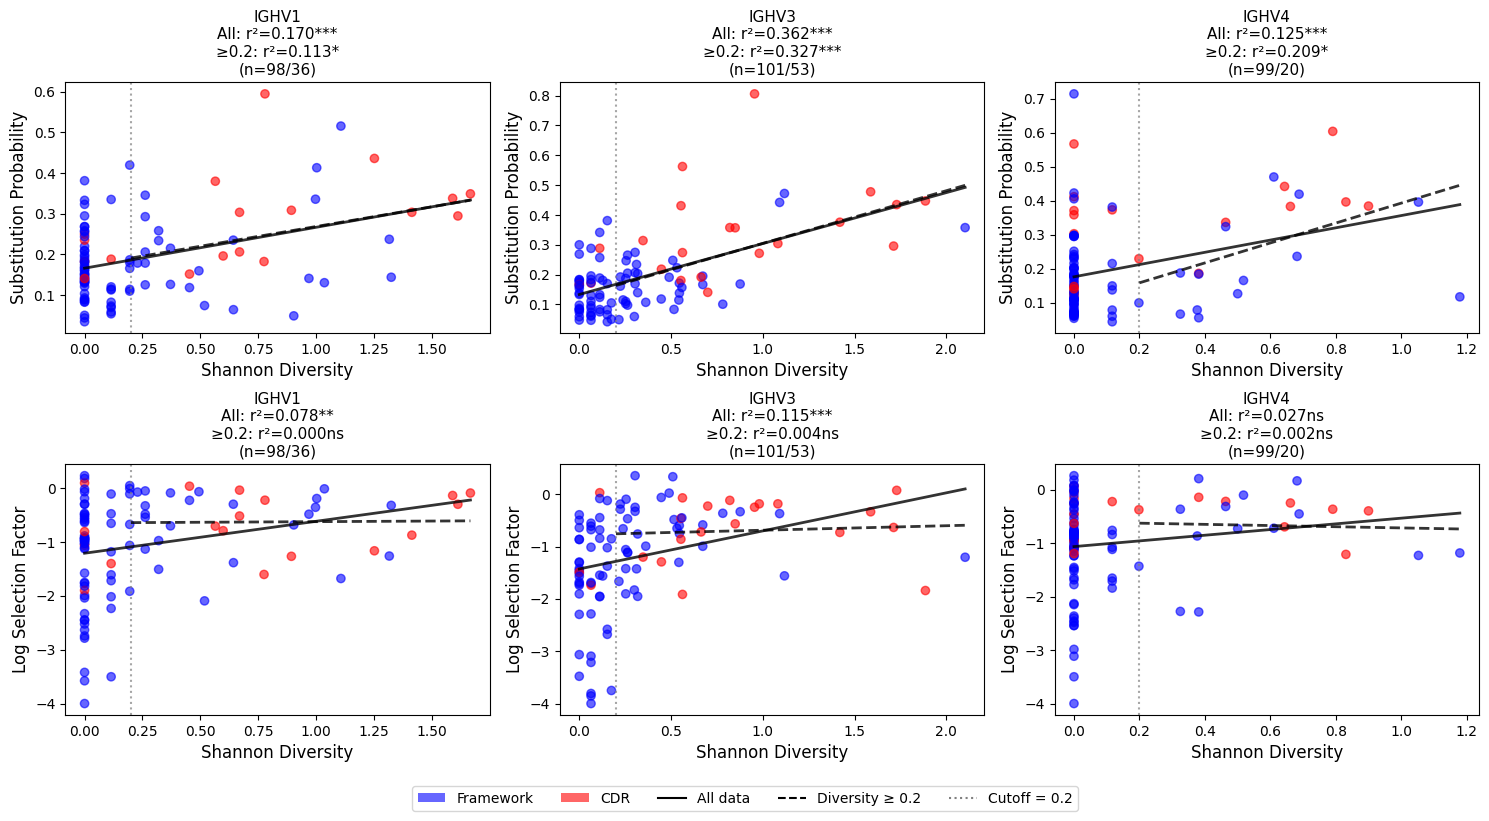

Blue = Framework regions, Red = CDR regions
Black solid line = regression using all data
Black dashed line = regression using only diversity ≥ 0.2
Gray dotted line = diversity cutoff at 0.2
Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant
n = total sites / filtered sites


In [19]:
# compare neutral substitution probabilities and DNSM selection factors with shannon diversity, group per site and v family. Only use 
# amino acids at their germline state to calculate median substitution probabilities.

neutral_grouped_data = MutabilityContainer.aa_to_any_neutral_df[(MutabilityContainer.aa_to_any_neutral_df.is_germline_aa == True) & (MutabilityContainer.aa_to_any_neutral_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'v_family', 'is_cdr'], sort=False).agg({'substitution_probability':'median'}).reset_index()
dnsm_grouped_data = site_sub_probs_df[(site_sub_probs_df.is_germline_aa == True) & (site_sub_probs_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'v_family'], sort=False).agg({'log_selection_factor':'median'}).reset_index()

compare_neutral_dnsm2 = pd.merge(neutral_grouped_data, dnsm_grouped_data, on=['site', 'v_family'], how='inner')
compare_neutral_dnsm2['log_selection_factor'] = compare_neutral_dnsm2['log_selection_factor'].clip(lower=-4)



# Merge the datasets
merged_data = pd.merge(diversity_by_family, 
                       compare_neutral_dnsm2.groupby(['site', 'v_family', 'is_cdr']).agg({'substitution_probability':'mean', 'log_selection_factor':'mean'}).reset_index(), 
                      left_on=['site', 'v_family'], 
                      right_on=['site', 'v_family'], 
                      how='inner')

# Calculate correlations for each v_family
correlation_results = []

for family in ['IGHV1', 'IGHV3', 'IGHV4']:
    family_data = merged_data[merged_data['v_family'] == family]
    
    if len(family_data) > 2:  # Need at least 3 points for correlation
        # Pearson correlations
        corr_subst_prob, p_subst_prob = pearsonr(family_data['shannon_diversity'], 
                                                family_data['substitution_probability'])
        corr_log_sel, p_log_sel = pearsonr(family_data['shannon_diversity'], 
                                          family_data['log_selection_factor'])
        
        # Spearman correlations (rank-based, more robust)
        spear_subst_prob, sp_subst_prob = spearmanr(family_data['shannon_diversity'], 
                                                   family_data['substitution_probability'])
        spear_log_sel, sp_log_sel = spearmanr(family_data['shannon_diversity'], 
                                             family_data['log_selection_factor'])
        
        correlation_results.append({
            'v_family': family,
            'n_sites': len(family_data),
            'pearson_subst_prob': corr_subst_prob,
            'p_value_subst_prob': p_subst_prob,
            'pearson_log_sel': corr_log_sel,
            'p_value_log_sel': p_log_sel,
            'spearman_subst_prob': spear_subst_prob,
            'spearman_p_subst_prob': sp_subst_prob,
            'spearman_log_sel': spear_log_sel,
            'spearman_p_log_sel': sp_log_sel
        })

# Display results
corr_df = pd.DataFrame(correlation_results)
print("Correlation Results by V-Family:")
print(corr_df.round(4))



fig, axes = plt.subplots(2, 3, figsize=(15, 8))

families = ['IGHV1', 'IGHV3', 'IGHV4']

def get_significance_stars(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"

for i, family in enumerate(families):
    family_data = merged_data[merged_data['v_family'] == family]
    family_filtered = family_data[family_data['shannon_diversity'] >= 0.2]
    
    # Calculate correlations for all data
    corr_subst, p_subst = pearsonr(family_data['shannon_diversity'], 
                                  family_data['substitution_probability'])
    corr_log_sel, p_log_sel = pearsonr(family_data['shannon_diversity'], 
                                      family_data['log_selection_factor'])
    r2_subst = corr_subst ** 2
    r2_log_sel = corr_log_sel ** 2
    
    # Calculate correlations for filtered data (diversity >= 0.2)
    if len(family_filtered) > 2:
        corr_subst_filt, p_subst_filt = pearsonr(family_filtered['shannon_diversity'], 
                                                family_filtered['substitution_probability'])
        corr_log_sel_filt, p_log_sel_filt = pearsonr(family_filtered['shannon_diversity'], 
                                                    family_filtered['log_selection_factor'])
        r2_subst_filt = corr_subst_filt ** 2
        r2_log_sel_filt = corr_log_sel_filt ** 2
    
    # Top row: Shannon vs Substitution Probability
    # Color by CDR/Framework
    axes[0, i].scatter(family_data['shannon_diversity'], 
                      family_data['substitution_probability'], 
                      alpha=0.6, 
                      c=family_data['is_cdr'].map({True: 'red', False: 'blue'}))
    axes[0, i].set_xlabel('Shannon Diversity', fontsize=12)
    axes[0, i].set_ylabel('Substitution Probability', fontsize=12)
    axes[0, i].tick_params(axis='both', which='major', labelsize=10)
    
    # Add vertical line at diversity = 0.2
    axes[0, i].axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
    
    # Regression line for all data
    z = np.polyfit(family_data['shannon_diversity'], 
                   family_data['substitution_probability'], 1)
    p = np.poly1d(z)
    x_range_all = np.linspace(family_data['shannon_diversity'].min(),
                             family_data['shannon_diversity'].max(), 100)
    axes[0, i].plot(x_range_all, p(x_range_all), "-", color='black', alpha=0.8, linewidth=2)
    
    # Regression line for filtered data (diversity >= 0.2) if enough points
    if len(family_filtered) > 2:
        z_filt = np.polyfit(family_filtered['shannon_diversity'], 
                           family_filtered['substitution_probability'], 1)
        p_filt = np.poly1d(z_filt)
        x_range_filt = np.linspace(max(0.2, family_data['shannon_diversity'].min()),
                                  family_data['shannon_diversity'].max(), 100)
        axes[0, i].plot(x_range_filt, p_filt(x_range_filt), "--", color='black', alpha=0.8, linewidth=2)
    
    # Title with correlation info (only r²)
    sig_stars = get_significance_stars(p_subst)
    title_text = f'{family}\nAll: r²={r2_subst:.3f}{sig_stars}'
    if len(family_filtered) > 2:
        sig_stars_filt = get_significance_stars(p_subst_filt)
        title_text += f'\n≥0.2: r²={r2_subst_filt:.3f}{sig_stars_filt}'
        title_text += f'\n(n={len(family_data)}/{len(family_filtered)})'
    else:
        title_text += f'\n(n={len(family_data)}, insufficient filtered data)'
    axes[0, i].set_title(title_text, fontsize=11)
    
    # Bottom row: Shannon vs Log Selection Factor
    axes[1, i].scatter(family_data['shannon_diversity'], 
                      family_data['log_selection_factor'], 
                      alpha=0.6,
                      c=family_data['is_cdr'].map({True: 'red', False: 'blue'}))
    axes[1, i].set_xlabel('Shannon Diversity', fontsize=12)
    axes[1, i].set_ylabel('Log Selection Factor', fontsize=12)
    axes[1, i].tick_params(axis='both', which='major', labelsize=10)
    
    # Add vertical line at diversity = 0.2
    axes[1, i].axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
    
    # Regression line for all data
    z2 = np.polyfit(family_data['shannon_diversity'], 
                    family_data['log_selection_factor'], 1)
    p2 = np.poly1d(z2)
    axes[1, i].plot(x_range_all, p2(x_range_all), "-", color='black', alpha=0.8, linewidth=2)
    
    # Regression line for filtered data (diversity >= 0.2) if enough points
    if len(family_filtered) > 2:
        z2_filt = np.polyfit(family_filtered['shannon_diversity'], 
                            family_filtered['log_selection_factor'], 1)
        p2_filt = np.poly1d(z2_filt)
        axes[1, i].plot(x_range_filt, p2_filt(x_range_filt), "--", color='black', alpha=0.8, linewidth=2)
    
    # Title with correlation info (only r²)
    sig_stars2 = get_significance_stars(p_log_sel)
    title_text2 = f'{family}\nAll: r²={r2_log_sel:.3f}{sig_stars2}'
    if len(family_filtered) > 2:
        sig_stars2_filt = get_significance_stars(p_log_sel_filt)
        title_text2 += f'\n≥0.2: r²={r2_log_sel_filt:.3f}{sig_stars2_filt}'
        title_text2 += f'\n(n={len(family_data)}/{len(family_filtered)})'
    else:
        title_text2 += f'\n(n={len(family_data)}, insufficient filtered data)'
    axes[1, i].set_title(title_text2, fontsize=11)

# Add a single legend for the entire figure
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.6, label='Framework'),
                  Patch(facecolor='red', alpha=0.6, label='CDR'),
                  plt.Line2D([0], [0], color='black', linestyle='-', label='All data'),
                  plt.Line2D([0], [0], color='black', linestyle='--', label='Diversity ≥ 0.2'),
                  plt.Line2D([0], [0], color='gray', linestyle=':', label='Cutoff = 0.2')]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=5, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)  # Make room for legend
plt.show()

print("Blue = Framework regions, Red = CDR regions")
print("Black solid line = regression using all data")
print("Black dashed line = regression using only diversity ≥ 0.2")
print("Gray dotted line = diversity cutoff at 0.2")
print("Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
print("n = total sites / filtered sites")

Correlations for All Data (Pooled across V-families):
Shannon Diversity vs Substitution Probability:
  r = 0.399, r² = 0.159, p = 0.000
Shannon Diversity vs Log Selection Factor:
  r = 0.386, r² = 0.149, p = 0.000
Shannon Diversity vs Selection Factor:
  r = 0.340, r² = 0.116, p = 0.000
Sample size: 298 sites


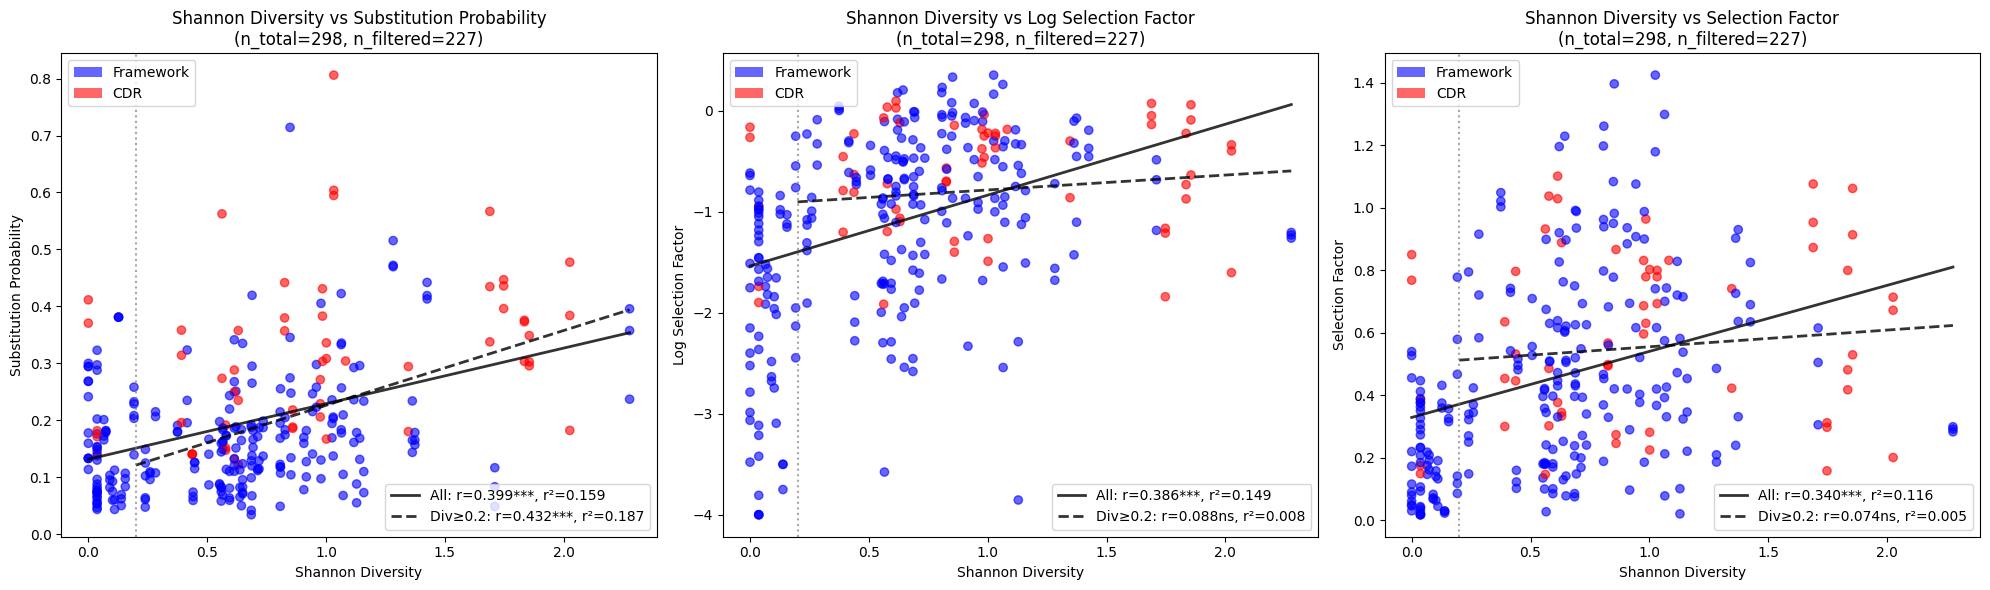

Solid line = regression using all data
Dashed line = regression using only diversity ≥ 0.2
Gray dotted line = diversity cutoff at 0.2
Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant


In [20]:
# compare neutral substitution probabilities and DNSM selection factors with shannon diversity per site and v family.
# Shannon diversity is calculated across all V1, V3, V4 germline sequences together, and substitution probabilities and selection factors are calculated
# per site and v family. All v families are plotted together.


# Calculate diversity across all families (pooled)
diversity_all_families = germline_df.groupby('site')['amino_acid'].apply(shannon_diversity).reset_index()
diversity_all_families.columns = ['site', 'shannon_diversity']

# Merge with your grouped data
merged_all_data = pd.merge(compare_neutral_dnsm2, diversity_all_families, on='site', how='inner')

# Add selection factor (non-log) if not already present
if 'selection_factor' not in merged_all_data.columns:
    merged_all_data['selection_factor'] = np.exp(merged_all_data['log_selection_factor'])

# Calculate correlations for all data pooled together
corr_subst_all, p_subst_all = pearsonr(merged_all_data['shannon_diversity'], 
                                      merged_all_data['substitution_probability'])
corr_log_sel_all, p_log_sel_all = pearsonr(merged_all_data['shannon_diversity'], 
                                          merged_all_data['log_selection_factor'])
corr_sel_all, p_sel_all = pearsonr(merged_all_data['shannon_diversity'], 
                                  merged_all_data['selection_factor'])

# Calculate r-squared
r2_subst_all = corr_subst_all ** 2
r2_log_sel_all = corr_log_sel_all ** 2
r2_sel_all = corr_sel_all ** 2

# Display results
print("Correlations for All Data (Pooled across V-families):")
print(f"Shannon Diversity vs Substitution Probability:")
print(f"  r = {corr_subst_all:.3f}, r² = {r2_subst_all:.3f}, p = {p_subst_all:.3f}")
print(f"Shannon Diversity vs Log Selection Factor:")
print(f"  r = {corr_log_sel_all:.3f}, r² = {r2_log_sel_all:.3f}, p = {p_log_sel_all:.3f}")
print(f"Shannon Diversity vs Selection Factor:")
print(f"  r = {corr_sel_all:.3f}, r² = {r2_sel_all:.3f}, p = {p_sel_all:.3f}")
print(f"Sample size: {len(merged_all_data)} sites")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))  # Added third subplot

def get_significance_stars(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"

# Filter data for second regression (diversity >= 0.2)
filtered_data = merged_all_data[merged_all_data['shannon_diversity'] >= 0.2]

# Add selection factor if not already present
if 'selection_factor' not in merged_all_data.columns:
    merged_all_data['selection_factor'] = np.exp(merged_all_data['log_selection_factor'])
    filtered_data['selection_factor'] = np.exp(filtered_data['log_selection_factor'])

# Calculate correlations for both datasets
# All data
corr_subst_all, p_subst_all = pearsonr(merged_all_data['shannon_diversity'], 
                                      merged_all_data['substitution_probability'])
corr_log_sel_all, p_log_sel_all = pearsonr(merged_all_data['shannon_diversity'], 
                                          merged_all_data['log_selection_factor'])
corr_sel_all, p_sel_all = pearsonr(merged_all_data['shannon_diversity'], 
                                  merged_all_data['selection_factor'])

r2_subst_all = corr_subst_all ** 2
r2_log_sel_all = corr_log_sel_all ** 2
r2_sel_all = corr_sel_all ** 2

# Filtered data (diversity >= 0.2)
corr_subst_filt, p_subst_filt = pearsonr(filtered_data['shannon_diversity'], 
                                        filtered_data['substitution_probability'])
corr_log_sel_filt, p_log_sel_filt = pearsonr(filtered_data['shannon_diversity'], 
                                            filtered_data['log_selection_factor'])
corr_sel_filt, p_sel_filt = pearsonr(filtered_data['shannon_diversity'], 
                                    filtered_data['selection_factor'])

r2_subst_filt = corr_subst_filt ** 2
r2_log_sel_filt = corr_log_sel_filt ** 2
r2_sel_filt = corr_sel_filt ** 2

# Plot 1: Shannon vs Substitution Probability
ax1.scatter(merged_all_data['shannon_diversity'], 
           merged_all_data['substitution_probability'], 
           alpha=0.6, c=merged_all_data['is_cdr'].map({True: 'red', False: 'blue'}))

z1_all = np.polyfit(merged_all_data['shannon_diversity'], 
                   merged_all_data['substitution_probability'], 1)
p1_all = np.poly1d(z1_all)
x_range_all = np.linspace(merged_all_data['shannon_diversity'].min(), 
                         merged_all_data['shannon_diversity'].max(), 100)
ax1.plot(x_range_all, p1_all(x_range_all), "k-", alpha=0.8, linewidth=2, 
         label=f'All: r={corr_subst_all:.3f}{get_significance_stars(p_subst_all)}, r²={r2_subst_all:.3f}')

z1_filt = np.polyfit(filtered_data['shannon_diversity'], 
                    filtered_data['substitution_probability'], 1)
p1_filt = np.poly1d(z1_filt)
x_range_filt = np.linspace(0.2, merged_all_data['shannon_diversity'].max(), 100)
ax1.plot(x_range_filt, p1_filt(x_range_filt), "k--", alpha=0.8, linewidth=2,
         label=f'Div≥0.2: r={corr_subst_filt:.3f}{get_significance_stars(p_subst_filt)}, r²={r2_subst_filt:.3f}')

ax1.axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
ax1.set_title(f'Shannon Diversity vs Substitution Probability\n(n_total={len(merged_all_data)}, n_filtered={len(filtered_data)})')
ax1.set_xlabel('Shannon Diversity')
ax1.set_ylabel('Substitution Probability')

# Plot 2: Shannon vs Log Selection Factor
ax2.scatter(merged_all_data['shannon_diversity'], 
           merged_all_data['log_selection_factor'], 
           alpha=0.6, c=merged_all_data['is_cdr'].map({True: 'red', False: 'blue'}))

z2_all = np.polyfit(merged_all_data['shannon_diversity'], 
                   merged_all_data['log_selection_factor'], 1)
p2_all = np.poly1d(z2_all)
ax2.plot(x_range_all, p2_all(x_range_all), "k-", alpha=0.8, linewidth=2,
         label=f'All: r={corr_log_sel_all:.3f}{get_significance_stars(p_log_sel_all)}, r²={r2_log_sel_all:.3f}')

z2_filt = np.polyfit(filtered_data['shannon_diversity'], 
                    filtered_data['log_selection_factor'], 1)
p2_filt = np.poly1d(z2_filt)
ax2.plot(x_range_filt, p2_filt(x_range_filt), "k--", alpha=0.8, linewidth=2,
         label=f'Div≥0.2: r={corr_log_sel_filt:.3f}{get_significance_stars(p_log_sel_filt)}, r²={r2_log_sel_filt:.3f}')

ax2.axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
ax2.set_title(f'Shannon Diversity vs Log Selection Factor\n(n_total={len(merged_all_data)}, n_filtered={len(filtered_data)})')
ax2.set_xlabel('Shannon Diversity')
ax2.set_ylabel('Log Selection Factor')

# Plot 3: Shannon vs Selection Factor (NEW)
ax3.scatter(merged_all_data['shannon_diversity'], 
           merged_all_data['selection_factor'], 
           alpha=0.6, c=merged_all_data['is_cdr'].map({True: 'red', False: 'blue'}))

z3_all = np.polyfit(merged_all_data['shannon_diversity'], 
                   merged_all_data['selection_factor'], 1)
p3_all = np.poly1d(z3_all)
ax3.plot(x_range_all, p3_all(x_range_all), "k-", alpha=0.8, linewidth=2,
         label=f'All: r={corr_sel_all:.3f}{get_significance_stars(p_sel_all)}, r²={r2_sel_all:.3f}')

z3_filt = np.polyfit(filtered_data['shannon_diversity'], 
                    filtered_data['selection_factor'], 1)
p3_filt = np.poly1d(z3_filt)
ax3.plot(x_range_filt, p3_filt(x_range_filt), "k--", alpha=0.8, linewidth=2,
         label=f'Div≥0.2: r={corr_sel_filt:.3f}{get_significance_stars(p_sel_filt)}, r²={r2_sel_filt:.3f}')

ax3.axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
ax3.set_title(f'Shannon Diversity vs Selection Factor\n(n_total={len(merged_all_data)}, n_filtered={len(filtered_data)})')
ax3.set_xlabel('Shannon Diversity')
ax3.set_ylabel('Selection Factor')

# Add legends to all plots
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.6, label='Framework'),
                  Patch(facecolor='red', alpha=0.6, label='CDR')]

for ax in [ax1, ax2, ax3]:
    ax_legend = ax.legend(handles=legend_elements, loc='upper left')
    ax.add_artist(ax_legend)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

print("Solid line = regression using all data")
print("Dashed line = regression using only diversity ≥ 0.2")
print("Gray dotted line = diversity cutoff at 0.2")
print("Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

#### a couple of sanity checks to compare to surprising sites:

In [21]:
### sanity check to surprising sites
MutabilityContainer.aa_neutral_df[(MutabilityContainer.aa_neutral_df.site == 24) &
                                  (MutabilityContainer.aa_neutral_df.v_gene == 'IGHV4-39*01')  &
                                  #(MutabilityContainer.aa_neutral_df.current_aa == 'T') &
                                  (MutabilityContainer.aa_neutral_df.is_germline_codon == True)
                                  ].groupby(
    ['current_aa', 'transition_aa']).agg({'substitution_probability':'median'}                               
                                  ).reset_index().sort_values('substitution_probability')



,current_aa,transition_aa,substitution_probability
2,(T),(N),0.026074
3,(T),(P),0.026932
5,(T),(T),0.041506
0,(T),(A),0.051756
1,(T),(I),0.063176
4,(T),(S),0.067917


In [22]:
### sanity check to surprising sites
MutabilityContainer.codon_neutral_df[(MutabilityContainer.codon_neutral_df.site == 24) &
                                  (MutabilityContainer.codon_neutral_df.v_gene == 'IGHV4-39*01')  &
                                  (MutabilityContainer.codon_neutral_df.is_germline_codon == True)
                                  ].groupby(
    ['current_codon', 'current_aa', 'transition_codon', 'transition_aa']).agg({'substitution_probability':'median'}                               
                                  ).reset_index().sort_values('substitution_probability')



,current_codon,current_aa,transition_codon,transition_aa,substitution_probability
4,ACT,(T),ACT,(T),0.000000
1,ACT,(T),ACA,(T),0.008859
3,ACT,(T),ACG,(T),0.012103
9,ACT,(T),TCT,(S),0.018800
2,ACT,(T),ACC,(T),0.020545
0,ACT,(T),AAT,(N),0.026074
7,ACT,(T),CCT,(P),0.026932
5,ACT,(T),AGT,(S),0.049117
8,ACT,(T),GCT,(A),0.051756
6,ACT,(T),ATT,(I),0.063176


In [23]:
### sanity check to surprising sites

MutabilityContainer.aa_neutral_df[(MutabilityContainer.aa_neutral_df.site == 24) &
                                  (MutabilityContainer.aa_neutral_df.v_gene == 'IGHV3-23*01') & 
                                  #(MutabilityContainer.aa_neutral_df.current_aa == 'T') &
                                  (MutabilityContainer.aa_neutral_df.is_germline_codon == True)].groupby(
    ['current_aa', 'transition_aa']).agg({'substitution_probability':'median'}                               
                                  ).reset_index().sort_values('substitution_probability')



,current_aa,transition_aa,substitution_probability
4,(A),(S),0.011346
3,(A),(P),0.017331
1,(A),(E),0.020990
2,(A),(G),0.031435
5,(A),(T),0.040861
6,(A),(V),0.047209
0,(A),(A),0.052803
